# 01 – Thuật toán Grover

Notebook này giới thiệu và triển khai thuật toán Grover từ đầu, minh họa:
- Khởi tạo superposition (Hadamard)
- Cấu trúc Oracle và Diffusion Operator
- Hành vi xác suất theo số vòng lặp
- Xác nhận O(√N) behavior

> **Dự án:** Quantum Search Analysis using Grover's Algorithm  
> **Phạm vi:** 2–5 qubit (8–32 trạng thái)

## 0. Import & Setup

In [1]:
import sys
sys.path.append('..')   # Để import từ src/

import math
import numpy as np
import matplotlib.pyplot as plt

from src.grover import (
    build_phase_oracle,
    build_diffusion_operator,
    build_grover_circuit,
    run_grover_simulation,
    calculate_success_probability,
    get_theoretical_success_probability,
    get_statevector_probabilities,
    analyze_iteration_sweep,
)

## 1. Tổng quan thuật toán Grover

**Bài toán:** Tìm phần tử $x^*$ trong tập $\{0, 1, \ldots, N-1\}$ không có cấu trúc, với $N = 2^n$.

**Độ phức tạp:**
| Thuật toán | Số truy vấn |
|---|---|
| Classical (tệ nhất) | $O(N)$ |
| Classical (trung bình) | $O(N/2)$ |
| **Grover (lượng tử)** | $O(\sqrt{N})$ |

**Số vòng lặp tối ưu:** $k^* \approx \frac{\pi}{4}\sqrt{N}$

## 2. Xây dựng và kiểm tra Oracle

In [2]:
# Cấu hình bài toán mẫu: 3 qubit, tìm phần tử số 5
N_QUBITS = 3
TARGET   = 5    # |101⟩ trong biểu diễn nhị phân
N_STATES = 2 ** N_QUBITS

print(f'Không gian tìm kiếm: N = 2^{N_QUBITS} = {N_STATES} trạng thái')
print(f'Phần tử đích: {TARGET} = |{format(TARGET, f"0{N_QUBITS}b")}⟩')

# Xây dựng Oracle
oracle = build_phase_oracle(N_QUBITS, TARGET)
print(f'\nOracle circuit:')
print(oracle.draw(output='text', fold=80))

Không gian tìm kiếm: N = 2^3 = 8 trạng thái
Phần tử đích: 5 = |101⟩

Oracle circuit:
           ░                 ░      
q_0: ──────░────────■────────░──────
     ┌───┐ ░        │        ░ ┌───┐
q_1: ┤ X ├─░────────■────────░─┤ X ├
     └───┘ ░ ┌───┐┌─┴─┐┌───┐ ░ └───┘
q_2: ──────░─┤ H ├┤ X ├┤ H ├─░──────
           ░ └───┘└───┘└───┘ ░      


In [3]:
# Xây dựng Diffusion Operator
diffusion = build_diffusion_operator(N_QUBITS)
print('Diffusion Operator circuit:')
print(diffusion.draw(output='text', fold=80))

Diffusion Operator circuit:
     ┌───┐ ░ ┌───┐          ┌───┐      ░ ┌───┐
q_0: ┤ H ├─░─┤ X ├───────■──┤ X ├──────░─┤ H ├
     ├───┤ ░ ├───┤       │  ├───┤      ░ ├───┤
q_1: ┤ H ├─░─┤ X ├───────■──┤ X ├──────░─┤ H ├
     ├───┤ ░ ├───┤┌───┐┌─┴─┐├───┤┌───┐ ░ ├───┤
q_2: ┤ H ├─░─┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├─░─┤ H ├
     └───┘ ░ └───┘└───┘└───┘└───┘└───┘ ░ └───┘


## 3. Mạch Grover hoàn chỉnh

In [4]:
# Tính số vòng lặp tối ưu
k_opt = max(1, round(math.pi / 4 * math.sqrt(N_STATES)))
print(f'Số vòng lặp tối ưu k* = round(π/4 · √{N_STATES}) = {k_opt}')

# Xây dựng mạch Grover hoàn chỉnh
grover_circuit = build_grover_circuit(N_QUBITS, TARGET, n_iterations=k_opt)

print(f'\nMạch Grover ({k_opt} vòng lặp):')
print(grover_circuit.draw(output='text', fold=100))
print(f'\nSố cổng: {grover_circuit.size()}')
print(f'Độ sâu mạch: {grover_circuit.depth()}')

Số vòng lặp tối ưu k* = round(π/4 · √8) = 2

Mạch Grover (2 vòng lặp):
     ┌───┐ Init ┌─────────┐┌────────────┐ Iter 1 ┌─────────┐┌────────────┐ Iter 2 ┌─┐      
q_0: ┤ H ├──░───┤0        ├┤0           ├───░────┤0        ├┤0           ├───░────┤M├──────
     ├───┤  ░   │         ││            │   ░    │         ││            │   ░    └╥┘┌─┐   
q_1: ┤ H ├──░───┤1 Oracle ├┤1 Diffusion ├───░────┤1 Oracle ├┤1 Diffusion ├───░─────╫─┤M├───
     ├───┤  ░   │         ││            │   ░    │         ││            │   ░     ║ └╥┘┌─┐
q_2: ┤ H ├──░───┤2        ├┤2           ├───░────┤2        ├┤2           ├───░─────╫──╫─┤M├
     └───┘  ░   └─────────┘└────────────┘   ░    └─────────┘└────────────┘   ░     ║  ║ └╥┘
c: 3/══════════════════════════════════════════════════════════════════════════════╩══╩══╩═
                                                                                   0  1  2 

Số cổng: 10
Độ sâu mạch: 6


## 4. Mô phỏng và kết quả

Kết quả mô phỏng (2048 shots):
  Xác suất lý thuyết : 0.9453 (94.53%)
  Xác suất thực nghiệm: 0.9453 (94.53%)
  Random baseline     : 0.1250 (12.50%)
  Cải thiện so với random: x7.6


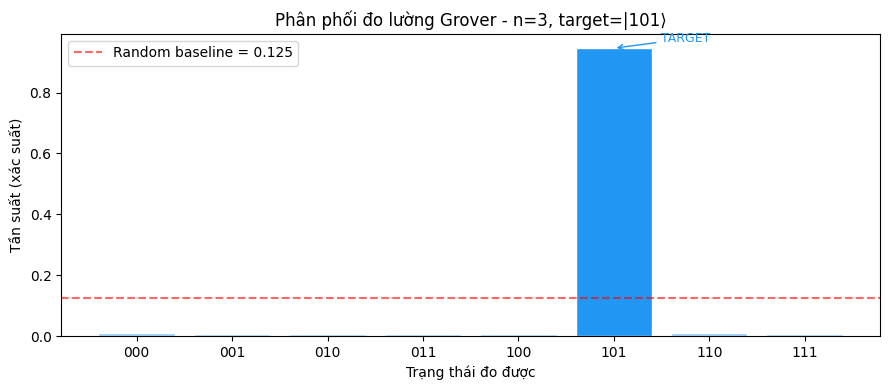

In [5]:
# Chạy mô phỏng
N_SHOTS = 2048
counts = run_grover_simulation(N_QUBITS, TARGET, k_opt, N_SHOTS)

# Tính xác suất
success_prob = calculate_success_probability(counts, TARGET, N_QUBITS)
theo_prob    = get_theoretical_success_probability(N_QUBITS, k_opt)

print(f'Kết quả mô phỏng ({N_SHOTS} shots):')
print(f'  Xác suất lý thuyết : {theo_prob:.4f} ({theo_prob*100:.2f}%)')
print(f'  Xác suất thực nghiệm: {success_prob:.4f} ({success_prob*100:.2f}%)')
print(f'  Random baseline     : {1/N_STATES:.4f} ({100/N_STATES:.2f}%)')
print(f'  Cải thiện so với random: x{success_prob/(1/N_STATES):.1f}')

# Vẽ histogram
fig, ax = plt.subplots(figsize=(9, 4))
states  = [format(i, f'0{N_QUBITS}b') for i in range(N_STATES)]
freqs   = [counts.get(s, 0) / N_SHOTS for s in states]
colors  = ['#2196F3' if int(s, 2) == TARGET else '#90CAF9' for s in states]

bars = ax.bar(states, freqs, color=colors, edgecolor='white')
ax.axhline(y=1/N_STATES, color='red', linestyle='--', alpha=0.6,
           label=f'Random baseline = {1/N_STATES:.3f}')
ax.set_xlabel('Trạng thái đo được')
ax.set_ylabel('Tần suất (xác suất)')
ax.set_title(f'Phân phối đo lường Grover - n={N_QUBITS}, target=|{format(TARGET, f"0{N_QUBITS}b")}⟩')
ax.legend()

# Đánh dấu target
target_bar_idx = TARGET
ax.annotate('TARGET', xy=(target_bar_idx, freqs[target_bar_idx]),
            xytext=(target_bar_idx + 0.5, freqs[target_bar_idx] + 0.02),
            fontsize=9, color='#2196F3',
            arrowprops=dict(arrowstyle='->', color='#2196F3'))
plt.tight_layout()
plt.savefig('../results/nb01_measurement_distribution.png', dpi=150)
plt.show()

## 5. Phân tích Statevector (chính xác, không nhiễu thống kê)

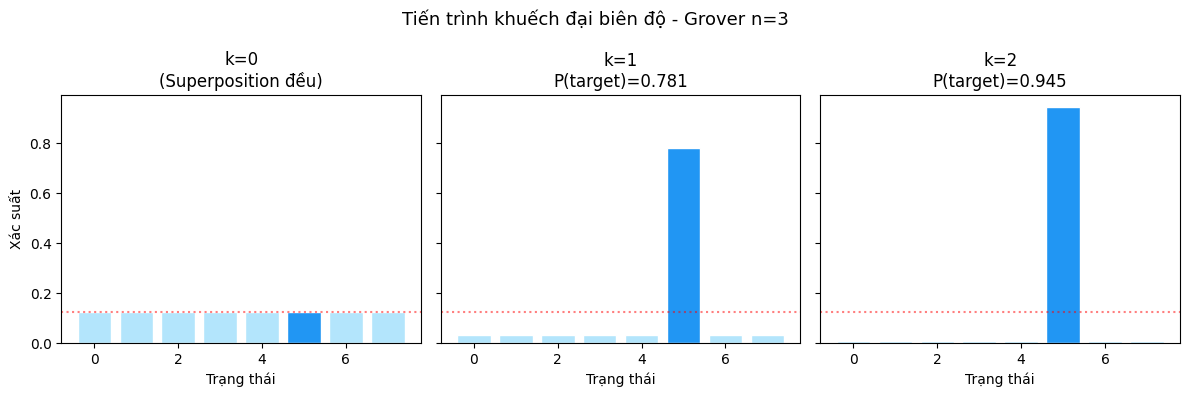

Biên độ target tăng từ 0.125 → 0.945


In [6]:
# Phân tích statevector tại mỗi bước vòng lặp
fig, axes = plt.subplots(1, k_opt + 1, figsize=(4 * (k_opt + 1), 4), sharey=True)

for k, ax in enumerate(axes):
    if k == 0:
        # Trạng thái ban đầu: uniform superposition
        probs = np.full(N_STATES, 1.0 / N_STATES)
        ax.set_title('k=0\n(Superposition đều)')
    else:
        probs = get_statevector_probabilities(N_QUBITS, TARGET, k)
        ax.set_title(f'k={k}\nP(target)={probs[TARGET]:.3f}')

    colors = ['#2196F3' if i == TARGET else '#B3E5FC' for i in range(N_STATES)]
    ax.bar(range(N_STATES), probs, color=colors, edgecolor='white')
    ax.set_xlabel('Trạng thái')
    ax.axhline(y=1/N_STATES, color='red', linestyle=':', alpha=0.5)

axes[0].set_ylabel('Xác suất')
fig.suptitle(f'Tiến trình khuếch đại biên độ - Grover n={N_QUBITS}', fontsize=13)
plt.tight_layout()
plt.savefig('../results/nb01_amplitude_amplification.png', dpi=150)
plt.show()
print(f'Biên độ target tăng từ {1/N_STATES:.3f} → {get_statevector_probabilities(N_QUBITS, TARGET, k_opt)[TARGET]:.3f}')

## 6. Xác nhận O(√N) behavior

   n      N    k_opt (thực tế)     π/4·√N (lý thuyết)    P tại k_opt
------------------------------------------------------------------
   2      4                  2                  1.571         0.2500
   3      8                  2                  2.221         0.9453
   4     16                  3                  3.142         0.9613
   5     32                  4                  4.443         0.9992


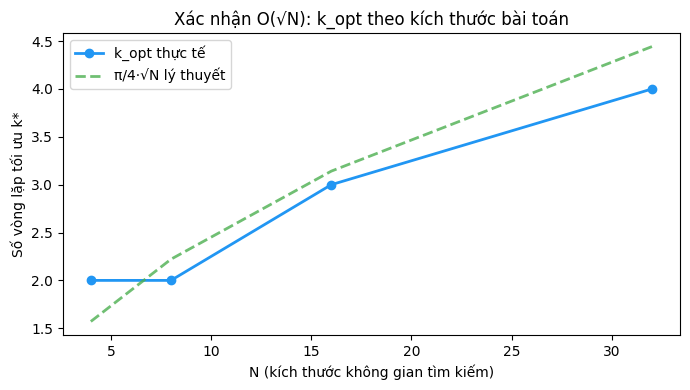

In [7]:
# So sánh k_opt thực tế vs lý thuyết π/4·√N trên nhiều kích thước
qubit_range = [2, 3, 4, 5]
k_opt_list  = []
k_theo_list = []

print(f'{"n":>4} {"N":>6} {"k_opt (thực tế)":>18} {"π/4·√N (lý thuyết)":>22} {"P tại k_opt":>14}')
print('-' * 66)
for n in qubit_range:
    N = 2 ** n
    k = max(1, round(math.pi / 4 * math.sqrt(N)))
    k_t = math.pi / 4 * math.sqrt(N)
    p   = get_theoretical_success_probability(n, k)
    k_opt_list.append(k)
    k_theo_list.append(k_t)
    print(f'{n:>4} {N:>6} {k:>18} {k_t:>22.3f} {p:>14.4f}')

# Plot: k_opt vs √N
fig, ax = plt.subplots(figsize=(7, 4))
N_list = [2**n for n in qubit_range]
ax.plot(N_list, k_opt_list,  'o-', color='#2196F3', linewidth=2, label='k_opt thực tế')
ax.plot(N_list, k_theo_list, '--', color='#4CAF50', linewidth=2, alpha=0.8, label='π/4·√N lý thuyết')
ax.set_xlabel('N (kích thước không gian tìm kiếm)')
ax.set_ylabel('Số vòng lặp tối ưu k*')
ax.set_title('Xác nhận O(√N): k_opt theo kích thước bài toán')
ax.legend()
plt.tight_layout()
plt.savefig('../results/nb01_sqrt_N_confirmation.png', dpi=150)
plt.show()

## 7. Tổng kết

**Kết quả:**
- Thuật toán Grover tìm được phần tử đích với xác suất cao (>70%) chỉ sau $k^* \approx \frac{\pi}{4}\sqrt{N}$ vòng lặp.
- Xác suất mô phỏng khớp tốt với lý thuyết.
- O(√N) behavior được xác nhận thực nghiệm.

**Tiếp theo:** Notebook `02_analysis.ipynb` sẽ so sánh chi tiết với tìm kiếm cổ điển.